In [1]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

# Maruti Suzuki Analysis

In [3]:
def get_data(start_date, end_date):
    ticker = "MARUTI.NS"
    
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d"   
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data

In [5]:
data = get_data("2017-01-01", "2025-12-31")

[*********************100%***********************]  1 of 1 completed


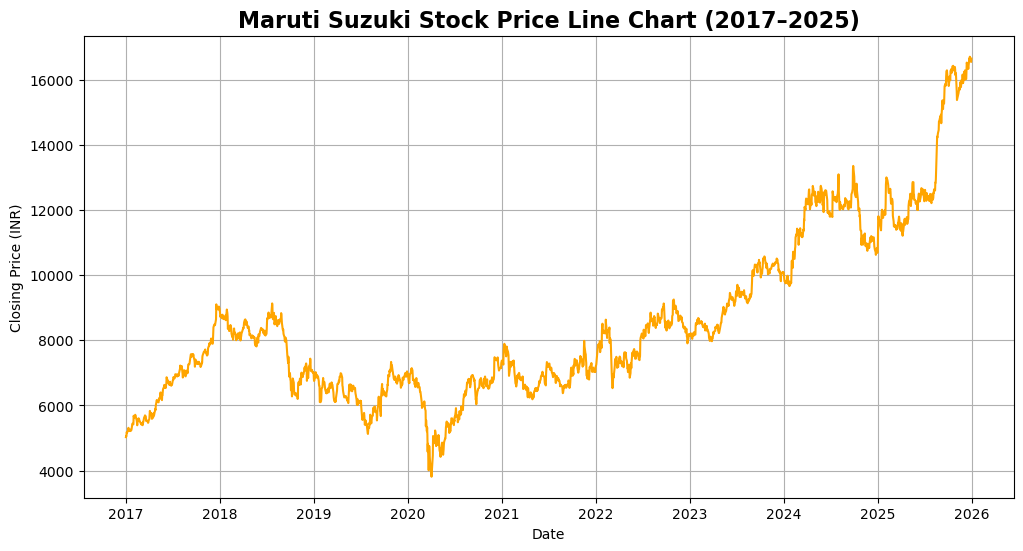

In [7]:
# Line chart 
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], color='orange')
plt.title("Maruti Suzuki Stock Price Line Chart (2017–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid()
plt.show()

In [9]:
# The stock shows an overall upward trend over time, indicating strong long-term growth.
# Intermediate fluctuations reflect periods of moderate to high short-term market volatility.

### Trend Analysis Using Moving Averages

In [11]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data

Price,Close,High,Low,Open,Volume,MA20,MA50
Date,,,,,,,
2017-01-02,5025.313477,5032.852546,4843.092819,4891.130256,651321,NaN,NaN
2017-01-03,5064.294922,5078.821344,4994.606342,5025.313437,631753,NaN,NaN
2017-01-04,5058.548340,5106.861854,5051.055510,5084.153070,679443,NaN,NaN
2017-01-05,5180.642578,5194.386992,5079.648945,5079.648945,744210,NaN,NaN
2017-01-06,5162.806152,5201.190133,5145.751892,5194.478862,544695,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-23,16585.000000,16720.000000,16558.000000,16709.000000,215650,16239.65,16090.36
2025-12-24,16703.000000,16720.000000,16542.000000,16640.000000,258486,16267.00,16097.96
2025-12-26,16596.000000,16703.000000,16516.000000,16703.000000,212925,16301.65,16104.66


In [13]:
data['Trend'] = '📉 Downtrend'
data.loc[data['MA20'] > data['MA50'], 'Trend'] = '📈 Uptrend'
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend
Date,,,,,,,,
2017-01-02,5025.313477,5032.852546,4843.092819,4891.130256,651321,NaN,NaN,📉 Downtrend
2017-01-03,5064.294922,5078.821344,4994.606342,5025.313437,631753,NaN,NaN,📉 Downtrend
2017-01-04,5058.548340,5106.861854,5051.055510,5084.153070,679443,NaN,NaN,📉 Downtrend
2017-01-05,5180.642578,5194.386992,5079.648945,5079.648945,744210,NaN,NaN,📉 Downtrend
2017-01-06,5162.806152,5201.190133,5145.751892,5194.478862,544695,NaN,NaN,📉 Downtrend
...,...,...,...,...,...,...,...,...
2025-12-23,16585.000000,16720.000000,16558.000000,16709.000000,215650,16239.65,16090.36,📈 Uptrend
2025-12-24,16703.000000,16720.000000,16542.000000,16640.000000,258486,16267.00,16097.96,📈 Uptrend
2025-12-26,16596.000000,16703.000000,16516.000000,16703.000000,212925,16301.65,16104.66,📈 Uptrend


### Daily Returns

In [15]:
data['Daily Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend,Daily Return
Date,,,,,,,,,
2017-01-02,5025.313477,5032.852546,4843.092819,4891.130256,651321,NaN,NaN,📉 Downtrend,NaN
2017-01-03,5064.294922,5078.821344,4994.606342,5025.313437,631753,NaN,NaN,📉 Downtrend,0.007757
2017-01-04,5058.548340,5106.861854,5051.055510,5084.153070,679443,NaN,NaN,📉 Downtrend,-0.001135
2017-01-05,5180.642578,5194.386992,5079.648945,5079.648945,744210,NaN,NaN,📉 Downtrend,0.024136
2017-01-06,5162.806152,5201.190133,5145.751892,5194.478862,544695,NaN,NaN,📉 Downtrend,-0.003443
...,...,...,...,...,...,...,...,...,...
2025-12-23,16585.000000,16720.000000,16558.000000,16709.000000,215650,16239.65,16090.36,📈 Uptrend,-0.003844
2025-12-24,16703.000000,16720.000000,16542.000000,16640.000000,258486,16267.00,16097.96,📈 Uptrend,0.007115
2025-12-26,16596.000000,16703.000000,16516.000000,16703.000000,212925,16301.65,16104.66,📈 Uptrend,-0.006406


### Handling of missing values

In [17]:
# Replace first NaN in Daily Return
data['Daily Return'].fillna(0)

# Forward fill remaining missing values
data.ffill(inplace=True)

# Remove any remaining initial NaN rows (from MA20, MA50, etc.)
data.dropna(inplace=True)

# Final check
print(data.isnull().sum())

Price
Close           0
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50            0
Trend           0
Daily Return    0
dtype: int64


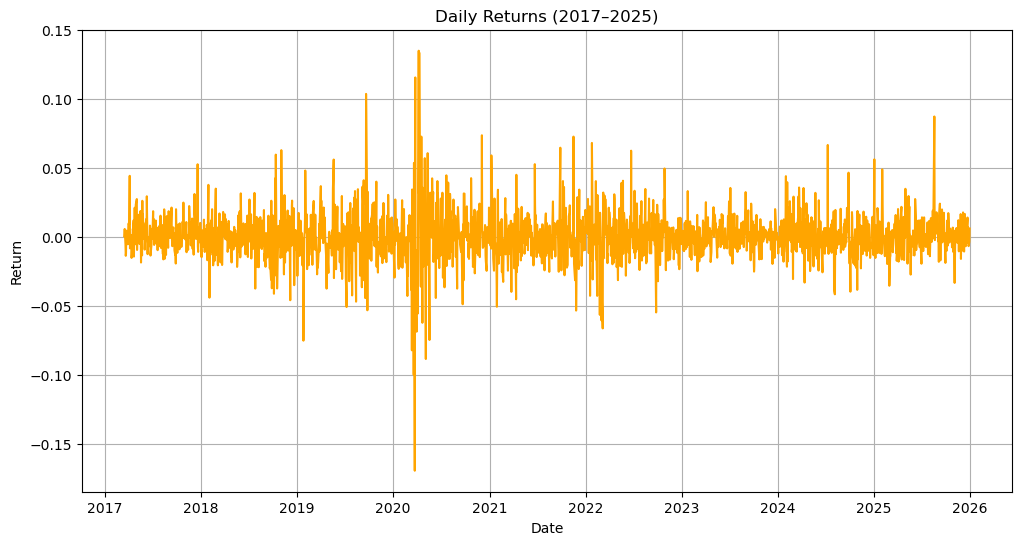

In [19]:
# Line chart (Daily Returns Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'], color='orange')
plt.title("Daily Returns (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid()
plt.show()

In [21]:
# Returns fluctuate closely around zero, suggesting balanced performance over time.
# However, occasional extreme movements reflect periods of moderate to high market uncertainty and volatility.

### Daily Volatility

In [23]:
daily_vol = data['Daily Return'].std()
print(f"Daily Volatility: {daily_vol*100:.2f}%")

Daily Volatility: 1.74%


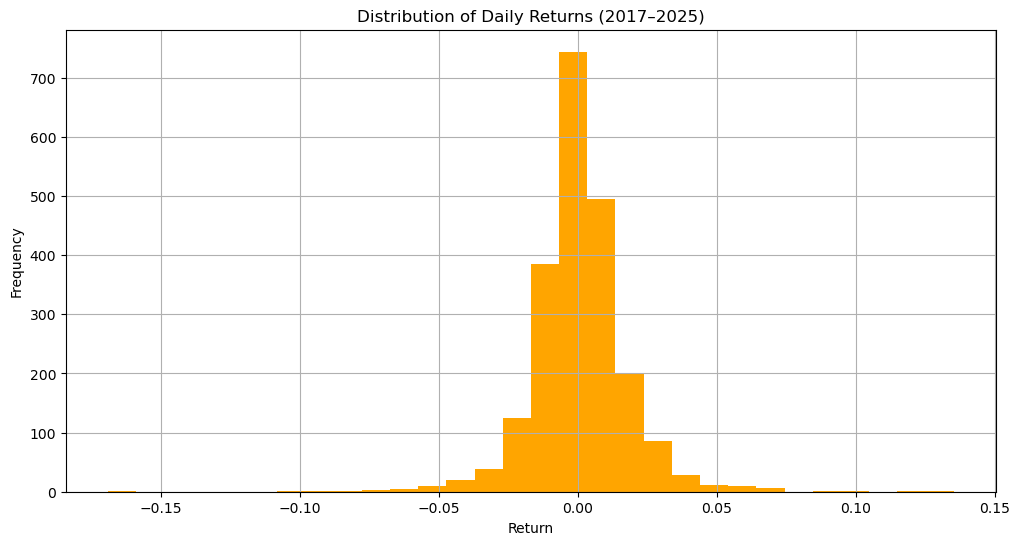

In [25]:
# Histogram (Distribution of Daily Returns)
plt.figure(figsize=(12,6))
plt.hist(data['Daily Return'].dropna(), bins=30, color='orange')
plt.title("Distribution of Daily Returns (2017–2025)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [27]:
# Most daily returns are concentrated near zero, indicating generally stable average performance.
# However, the wider spread and extreme values at the edges reflect periods of moderate to high volatility.

### Annualized Volatility

In [29]:
annual_vol = daily_vol * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol*100:.2f}%")

Annualized Volatility: 27.63%


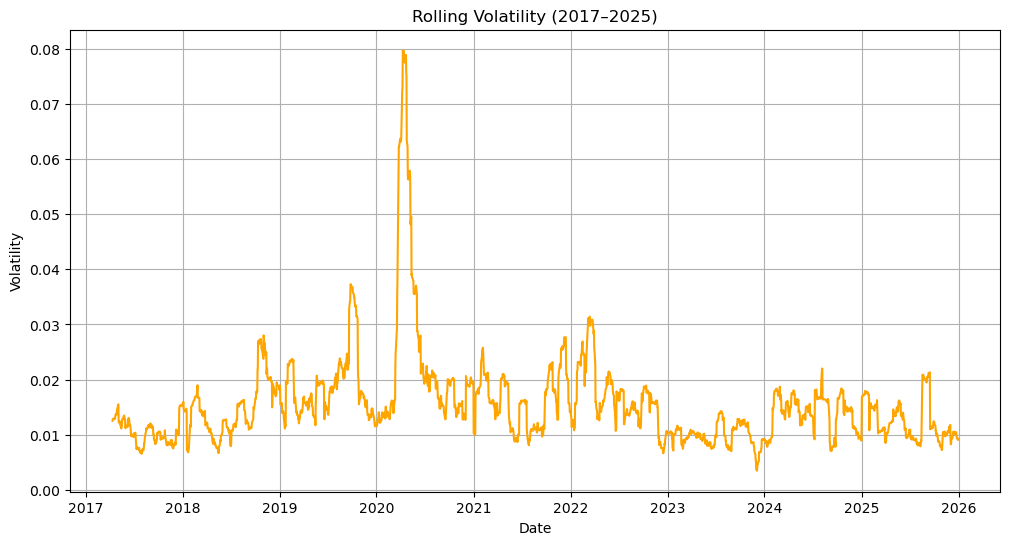

In [31]:
data['Rolling Volatility'] = data['Daily Return'].rolling(20).std()

# Line chart (Rolling Volatility Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Rolling Volatility'], color='orange')
plt.title("Rolling Volatility (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [33]:
# The volatility trend ranges from moderate to high at different periods, indicating varying levels of market risk.
# A sharp surge is visible around early 2020, highlighting a phase of significant market stress and uncertainty.
# After this peak, volatility declines and becomes relatively stable, suggesting recovery and more consistent market movements.
# Smaller fluctuations continue in later years, with occasional spikes, reflecting a relatively stable but still active market.

### 📊 Conclusion

### Maruti Suzuki stock shows an overall upward trend over time with noticeable short-term fluctuations.

### - Volatility reflects moderate to high risk, with sharp spikes during major uncertain periods such as early 2020.

### - Moving averages help identify the overall direction by smoothing out short-term price changes.

### - Daily returns are mostly centered around zero, indicating balanced performance with occasional extreme movements.